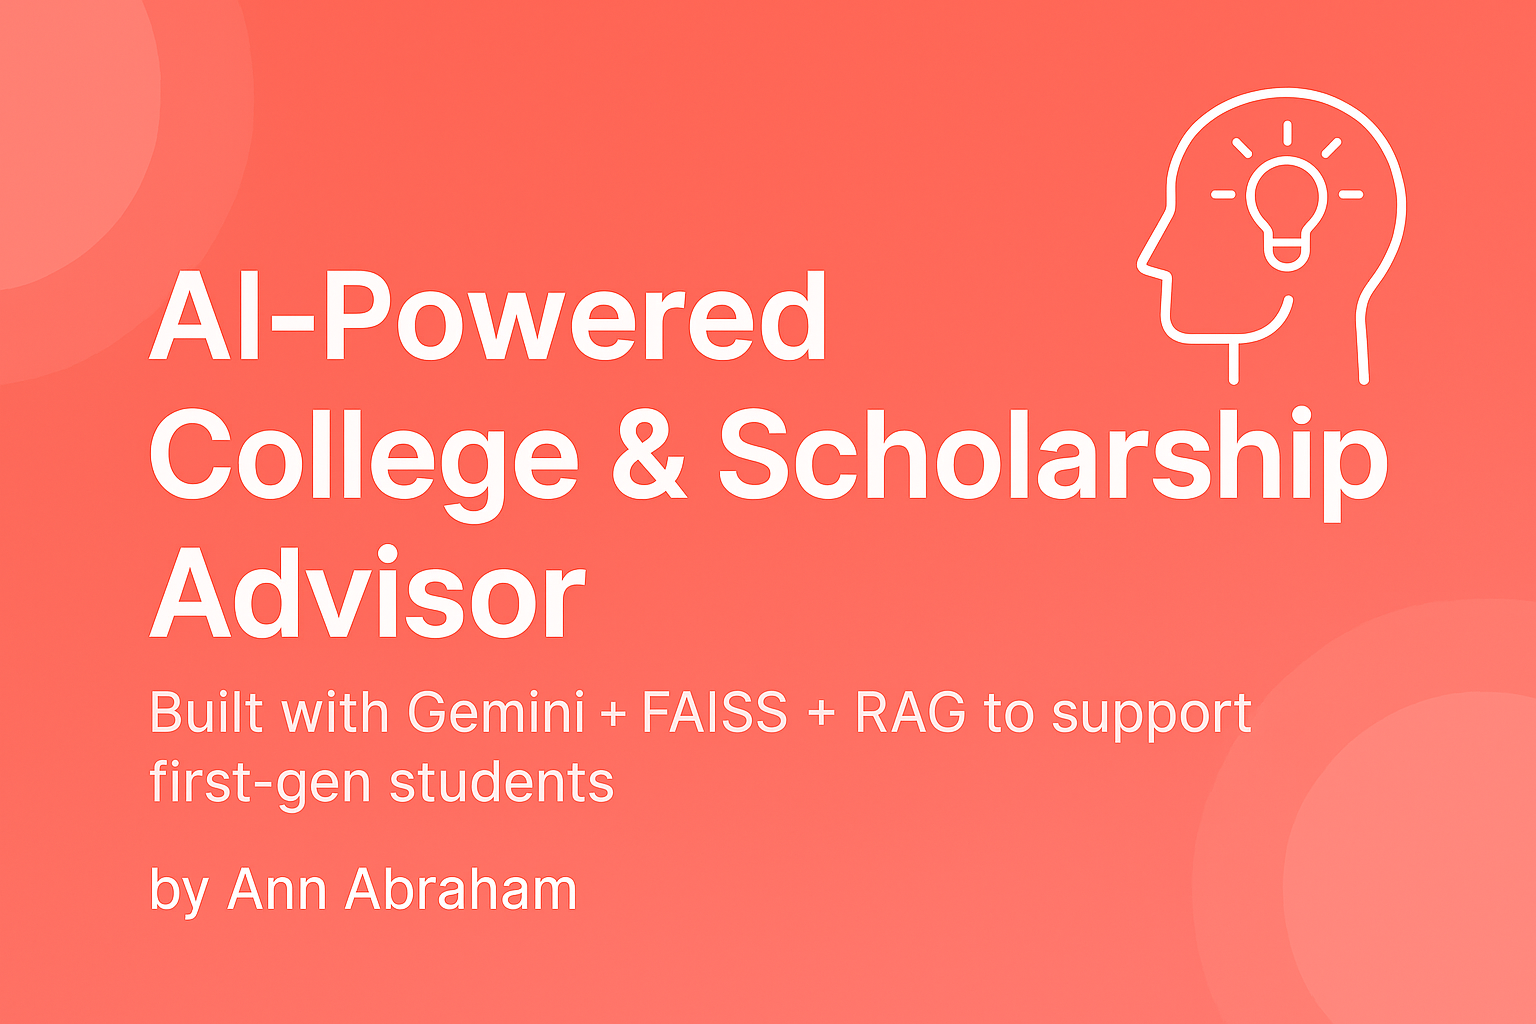

In [25]:
from IPython.display import Image, display
display(Image("/kaggle/input/title-header/ChatGPT Image Apr 16 2025 09_09_41 PM.png"))

# 🎓 PathFinder AI – Smart College Counseling Assistant

Helping first-generation high school students discover personalized college, scholarship, and activity opportunities using GenAI + RAG.

💡 *What if every student had a personalized, intelligent college advisor powered by GenAI?*

## 🧠 Problem Statement

First-generation students face challenges navigating:

- College selection and admissions requirements
- Financial aid options and scholarship access
- Choosing extracurriculars aligned with academic goals

This notebook introduces **PathFinder AI**, a personalized college advisor built using Generative AI.


## ✅ GenAI Capabilities Demonstrated

| Capability | How It’s Used |
|------------|----------------|
| ✅ Structured Output | Gemini JSON with rationale and scoring |
| ✅ Retrieval-Augmented Generation (RAG) | FAISS + Gemini for relevant responses |
| ✅ Grounding | Injected context from semantic search results |
| ✅ Embeddings + Vector Search | SentenceTransformer and FAISS |
| ✅ Prompt Engineering | Templated prompt design with scores |
| ✅ Context Caching | Cache repeated user queries for performance |


### 📥 Imports & Setup

In [26]:
!pip install faiss-cpu ipywidgets feedparser

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [27]:
import os, json, time, requests
import pandas as pd
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import google.generativeai as genai
from kaggle_secrets import UserSecretsClient
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

#### 🔐 Load Gemini API Key and College Score Card API Key

In [28]:
GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
COLLEGE_SCORECARD_API_KEY = UserSecretsClient().get_secret("COLLEGE_SCORECARD_API_KEY")
genai.configure(api_key=GOOGLE_API_KEY)
gemini_model = genai.GenerativeModel("gemini-2.0-flash")
chat = gemini_model.start_chat()

### 📊 Load Datasets
##### 🎓 Fetch live College Scorecard data

In [29]:
def fetch_live_college_data(
    states=None,
    per_state_limit=50,
    cache_path="college_scorecard_cache_by_state.json",
    use_cache=True
):
    BASE_URL = "https://api.data.gov/ed/collegescorecard/v1/schools.json"
    COLLEGE_SCORECARD_API_KEY = UserSecretsClient().get_secret("COLLEGE_SCORECARD_API_KEY")

    if use_cache and os.path.exists(cache_path):
        print("🔁 Loading cached college data by state...")
        with open(cache_path, "r") as f:
            results = json.load(f)
    else:
        #print("🔍 Fetching college data by state...")

        # Default to 20+ key U.S. states if not provided
        if states is None:
            states = ['CA', 'NY', 'TX', 'FL', 'IL', 'WA', 'GA', 'PA', 'OH', 'MI',
                      'NC', 'VA', 'AZ', 'MA', 'CO', 'NJ', 'IN', 'MO', 'WI', 'TN']

        results = []
        for state in states:
            params = {
                "api_key": COLLEGE_SCORECARD_API_KEY,
                "fields": "school.name,school.city,school.state,school.control,"
                          "2022.cost.tuition.in_state,2022.admissions.admission_rate.overall,"
                          "2022.admissions.sat_scores.average.overall",
                "school.state": state,
                "per_page": per_state_limit,
                "page": 0
            }
            try:
                r = requests.get(BASE_URL, params=params)
                if r.status_code == 200:
                    state_data = r.json()["results"]
                    results.extend(state_data)
                    #print(f"✅ {len(state_data)} colleges loaded from {state}")
                else:
                    print(f"⚠️ Failed to fetch {state}: Status {r.status_code}")
            except Exception as e:
                print(f"❌ Error fetching {state}: {e}")
            time.sleep(0.3)

        # Save to cache
        with open(cache_path, "w") as f:
            json.dump(results, f)

    # Convert to DataFrame
    df = pd.DataFrame(results).dropna()

    df.rename(columns={
        "school.name": "College Name",
        "school.city": "City",
        "school.state": "State",
        "2022.cost.tuition.in_state": "Tuition",
        "2022.admissions.admission_rate.overall": "Acceptance Rate",
        "2022.admissions.sat_scores.average.overall": "Avg SAT"
    }, inplace=True)

    def get_value(row, primary, fallback):
        return row.get(primary) or row.get(fallback)

    # Generate Description for use in RAG
    df["Description"] = df.apply(lambda row: (
        f"{get_value(row, 'College Name', 'school.name')} in "
        f"{get_value(row, 'City', 'school.city')}, "
        f"{get_value(row, 'State', 'school.state')} is a "
        f"Tuition: ${row.get('Tuition', row.get('2022.cost.tuition.in_state'))}, "
        f"Acceptance Rate: {row.get('Acceptance Rate', row.get('2022.admissions.admission_rate.overall')):.2f}, "
        f"Avg SAT: {row.get('Avg SAT', row.get('2022.admissions.sat_scores.average.overall'))}."
    ), axis=1)

    return df

### 🧠 Embeddings + Vector Search
 We use SentenceTransformer to embed dataset entries (colleges and scholarships) and the user’s profile into vector space.
 Then, FAISS performs fast semantic similarity search to find the best matches.

In [30]:
def build_faiss_index_from_descriptions(df, column="Description"):
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(df[column].tolist())
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(np.array(embeddings))
    return model, index, embeddings

college_df = fetch_live_college_data(per_state_limit=50)
scholarship_df = pd.read_csv('/kaggle/input/world-scholarships/Universities_Schoolarships_All_Around_the_World.csv', index_col=0)

# Drop rows with NaN in any of the relevant columns
required_cols = ["title", "degrees", "funds", "date", "location"]
filtered_df = scholarship_df.dropna(subset=required_cols).copy()

#Filter to only U.S.-based scholarships
scholarship_df = filtered_df[filtered_df["location"].str.lower() == "united-states"].copy()

# Rename the 'title' column to 'Scholarship Name' for consistency
scholarship_df.rename(columns={"title": "Scholarship Name"}, inplace=True)

# Build a formatted Description column
scholarship_df["Description"] = scholarship_df.apply(lambda row: (
    f"{row['Scholarship Name']} is a {row['degrees']} scholarship available in the United States.\n"
    f"Funding: {row['funds']}, Deadline: {row['date']}."
), axis=1)

# Optional: Preview or export
scholarship_df[["Scholarship Name", "Description"]].head()

embed_model, college_index, college_embeddings = build_faiss_index_from_descriptions(college_df)
_, scholarship_index, scholarship_embeddings = build_faiss_index_from_descriptions(scholarship_df)

#print(f"✅ Loaded {len(college_df)} colleges and {len(scholarship_df)} scholarships.")

🔁 Loading cached college data by state...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## 🧠 Core GenAI Engine: `CollegeRAGAdvisor`

This class serves as the heart of our GenAI system, orchestrating multiple advanced capabilities:

### ✅ GenAI Capabilities Demonstrated

| Capability | Where It’s Used |
|------------|------------------|
| ✅ **Embeddings + Vector Search** | Encodes college and scholarship descriptions using `SentenceTransformer` and indexes them with FAISS for similarity search |
| ✅ **Retrieval-Augmented Generation (RAG)** | Retrieves top K relevant entries and injects them into the Gemini prompt |
| ✅ **Grounding** | Includes factual descriptions and similarity scores to guide Gemini’s output |
| ✅ **Prompt Engineering** | Constructs a carefully formatted prompt that defines structure, sections, and expected output format |
| ✅ **Structured Output** | Instructs Gemini to respond using JSON, which is parsed and displayed later |
| ✅ **Context Caching** *(Optional/extendable)* | You can cache repeated responses using a dictionary (`self.cache`) to avoid redundant calls

---

### 📌 How It Works

1. **Embedding & Indexing**  
   College and scholarship descriptions are embedded into vector space and indexed using FAISS.

2. **Semantic Retrieval**  
   The user’s profile is also embedded and used to retrieve the most relevant entries from the index.

3. **Prompt Construction**  
   Retrieved entries and similarity scores are inserted into a templated prompt, along with the user’s query.

4. **LLM Recommendation**  
   The prompt is sent to Gemini, which returns structured recommendations based on grounded context.

---

This modular class enables dynamic, explainable, and context-aware recommendations using best practices in GenAI engineering.


In [31]:
class CollegeRAGAdvisor:
    def __init__(self, college_df, scholarship_df, chat, embedding_model, k_colleges=3, k_scholarships=2):
        self.college_df = college_df
        self.scholarship_df = scholarship_df
        self.chat = chat
        self.model = embedding_model
        self.k_colleges = k_colleges
        self.k_scholarships = k_scholarships
        self.cache = {}
        self._create_faiss_indices()

    def _create_faiss_indices(self):
        # Embed and index college descriptions
        self.college_embeddings = self.model.encode(self.college_df["Description"].tolist())
        self.college_index = faiss.IndexFlatL2(self.college_embeddings.shape[1])
        self.college_index.add(np.array(self.college_embeddings))

        # Embed and index scholarship descriptions
        self.scholarship_embeddings = self.model.encode(self.scholarship_df["Description"].tolist())
        self.scholarship_index = faiss.IndexFlatL2(self.scholarship_embeddings.shape[1])
        self.scholarship_index.add(np.array(self.scholarship_embeddings))
    def _retrieve_context(self, query):
        query_embedding = self.model.encode([query])

        college_dists, college_ids = self.college_index.search(np.array(query_embedding), self.k_colleges)
        top_colleges = self.college_df.iloc[college_ids[0]].copy()

        scholarship_dists, scholarship_ids = self.scholarship_index.search(np.array(query_embedding), self.k_scholarships)
        top_scholarships = self.scholarship_df.iloc[scholarship_ids[0]].copy()

        return top_colleges, top_scholarships, college_dists[0], scholarship_dists[0]

    def _build_prompt(self, query, colleges, scholarships, college_dists, scholarship_dists):
        context = "### College Info (with similarity scores):\n"
        for (idx, row), dist in zip(colleges.iterrows(), college_dists):
            context += f"- {row['College Name']} (Distance: {dist:.4f}): {row['Description']}\n"

        context += "\n### Scholarship Info (with similarity scores):\n"
        for (idx, row), dist in zip(scholarships.iterrows(), scholarship_dists):
            context += f"- {row['Scholarship Name']} (Distance: {dist:.4f}): {row['Description']}\n"

        full_prompt = (
            f"You are an expert college advisor. Use the context below to generate "
            f"personalized college and scholarship recommendations for the following user:\n\n"
            f"{context}\n"
            f"\n### User Profile:\n{query}\n"
            f"\nPlease return your answer in this JSON format:\n"
            f"```\n"
            f"{{\n"
            f'  "college_recommendations": [{{"college": "...", "rationale": "..."}}],\n'
            f'  "extracurricular_suggestions": [{{"activity": "...", "rationale": "..."}}],\n'
            f'  "scholarship_recommendation": {{"scholarship": "...", "eligibility": "..."}}\n'
            f"}}\n"
            f"```"
        )
        return full_prompt

    def recommend(self, user_query, preferred_state=None, degree_level=None):
        if user_query in self.cache:
            print("🔁 Using cached result.")
            response_dict = self.cache[user_query]
        else:
            self.chat = self.chat.model.start_chat()  # Reset context to avoid hallucinations
    
            # 🔍 Filtering
            filtered_df = self.college_df.copy()
            if preferred_state and preferred_state not in ["Select one", "Other"]:
                filtered_df = filtered_df[filtered_df["State"] == preferred_state]

            # You can add degree-based filtering if your dataset has that column
            # if degree_level and degree_level not in ["Select one"]:
            #     filtered_df = filtered_df[filtered_df["Offered Degrees"].str.contains(degree_level, case=False)]
    
            cache_key = (preferred_state or "ALL", degree_level or "ALL")
    
            if not hasattr(self, "filtered_index_cache"):
                self.filtered_index_cache = {}
            if cache_key in self.filtered_index_cache:
                print(f"✅ Using cached index for {cache_key}")
                filtered_df, temp_index = self.filtered_index_cache[cache_key]
            else:
                if filtered_df.empty:
                    print("❗ No colleges matched filter. Using full dataset.")
                    filtered_df = self.college_df
                college_embeddings = self.model.encode(filtered_df["Description"].tolist())
                temp_index = faiss.IndexFlatL2(college_embeddings.shape[1])
                temp_index.add(np.array(college_embeddings))
                self.filtered_index_cache[cache_key] = (filtered_df, temp_index)
    
            # 🔎 Search colleges
            query_embedding = self.model.encode([user_query])
            college_dists, college_ids = temp_index.search(np.array(query_embedding), self.k_colleges)
            top_colleges = filtered_df.iloc[college_ids[0]].copy()
    
            # 🧠 Scholarships (no filter)
            scholarship_dists, scholarship_ids = self.scholarship_index.search(np.array(query_embedding), self.k_scholarships)
            top_scholarships = self.scholarship_df.iloc[scholarship_ids[0]].copy()
    
            # 🧾 Prompt + Gemini response
            prompt = self._build_prompt(user_query, top_colleges, top_scholarships, college_dists[0], scholarship_dists[0])
            response = self.chat.send_message(prompt)
    
            cleaned_text = response.text.strip()   
            if cleaned_text.startswith("```json"):
                cleaned_text = cleaned_text[7:]
            if cleaned_text.endswith("```"):
                cleaned_text = cleaned_text[:-3]  
            try:
                response_dict = json.loads(cleaned_text)
                self.cache[user_query] = response_dict
            except json.JSONDecodeError:
                print("❌ Failed to parse JSON. Raw output:\n", cleaned_text)
                return
    
        # 📋 Display output
        from IPython.display import display, Markdown
        md = "# 🎓 College Recommendations\n"
        for college in response_dict["college_recommendations"]:
            md += f"## {college['college']}\n{college['rationale']}\n\n"
    
        md += "## 🏫 Extracurricular Suggestions\n"
        for item in response_dict["extracurricular_suggestions"]:
            md += f"- **{item['activity']}**\n  - {item['rationale']}\n"

        sch = response_dict["scholarship_recommendation"]
        md += "\n## 💰 Scholarship Recommendation\n"
        md += f"**Scholarship:** {sch['scholarship']}\n\n"
        md += f"**Eligibility:** {sch['eligibility']}\n"
    
        display(Markdown(md))    


## 🚀 Instantiate the GenAI Advisor

Now that we’ve defined the `CollegeRAGAdvisor` class, we create an instance of it using:

- The live or preprocessed **college and scholarship datasets**
- The **Gemini chat interface** (via `google.generativeai`)
- The **SentenceTransformer embedding model**
- Parameters like:
  - `k_colleges=5`: Number of college recommendations to retrieve
  - `k_scholarships=3`: Number of scholarships to include

This object will be passed into our interactive UI to power real-time, grounded, GenAI-based recommendations.


In [32]:
advisor = CollegeRAGAdvisor(
    college_df=college_df,
    scholarship_df=scholarship_df,
    chat=chat,
    embedding_model=embed_model,
    k_colleges=5,
    k_scholarships=3
)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## 🖼️ Interactive UI with ipywidgets

To make this system user-friendly and accessible, we’ve built a custom interactive UI using `ipywidgets`.

This UI allows users to:

- ✍️ Enter their academic profile and background
- 🎯 Choose a preferred degree and state (optional)
- 💰 Select scholarship preferences
- 🚀 Trigger the GenAI recommendation system with a single click

---

### ✅ Capabilities Supported in the UI:

| GenAI Element | Where It Appears |
|---------------|------------------|
| 🧠 User Prompt | Text input box captures user profile, interests |
| 🎛️ Parameter Control | Dropdowns for degree and state filter results |
| 🤖 Real-Time Inference | Calls `CollegeRAGAdvisor.recommend()` using Gemini |
| 📊 Structured Output Rendering | Parses and displays JSON results with Markdown formatting |

---

### 🧩 How the UI Works:

1. **Collects inputs** via form-style interface (text box + dropdowns)
2. **Builds a user query** string based on inputs
3. **Passes it to the advisor** which performs RAG + Gemini recommendation
4. **Displays colleges, scholarships, and extracurriculars** in a clean format

> This makes the system accessible to educators, students, and counselors — no coding needed.



In [33]:
def run_tabbed_ui(advisor):
    DEGREE_OPTIONS = ["Select one", "Bachelor", "Master", "PhD"]
    state_list = sorted(college_df["State"].dropna().unique().tolist())
    STATE_OPTIONS = ["Select one"] + state_list

    profile_input = widgets.Textarea(
        placeholder="E.g. I am a first-gen student interested in psychology, and I need financial aid.",
        layout=widgets.Layout(width='100%', height='100px')
    )

    interest_input = widgets.Textarea(
        placeholder="E.g. Speech and debate, swimming, video games, black belt in martial arts, N5 Japanese",
        layout=widgets.Layout(width='100%', height='100px')
    )

    degree_dropdown = widgets.Dropdown(
        options=DEGREE_OPTIONS,
        value="Select one",
        description="Degree:"
    )

    state_dropdown = widgets.Dropdown(
        options=STATE_OPTIONS,
        value="Select one",
        description="State:"
    )
    
    scholarship_type = widgets.Dropdown(
        options=["Any", "Fully Funded", "Partially Funded", "Tuition-Based", "Merit-Based"],
        value="Any",
        description="Scholarship:"
    )

    run_button = widgets.Button(
        description='Get Recommendations',
        button_style='primary',
        icon='💡'
    )

    output = widgets.Output()
    error_box = widgets.Output()

    tab1 = widgets.VBox([widgets.HTML("<b>👤 Academic Profile</b>"), profile_input, degree_dropdown, state_dropdown])
    tab2 = widgets.VBox([widgets.HTML("<b>🎯 Activities & Certifications</b>"), interest_input])
    tab3 = widgets.VBox([widgets.HTML("<b>💰 Scholarship Preferences</b>"), scholarship_type])
    tab4 = widgets.VBox([error_box, widgets.HTML("<b>📋 Recommended Colleges & Scholarships</b>"), output])

    tabs = widgets.Tab(children=[tab1, tab2, tab3, tab4])
    tabs.set_title(0, "Profile")
    tabs.set_title(1, "Interests")
    tabs.set_title(2, "Scholarships")
    tabs.set_title(3, "Results")

    def on_click(_):
            with output:
                clear_output()
            with error_box:
                clear_output()
        
            # ✅ Validate profile and degree
            invalid_profile = not profile_input.value.strip()
            invalid_degree = not degree_dropdown.value or degree_dropdown.value == "Select one"
        
            if invalid_profile or invalid_degree:
                with error_box:
                    display(Markdown("❗ **Please enter your academic profile and select a degree. State is optional.**"))
                tabs.selected_index = 3
                return
    
            query = (
                f"{profile_input.value.strip()}\n\n"
                f"Activities: {interest_input.value.strip()}\n"
                f"Degree: {degree_dropdown.value}, "
                f"Preferred State: {state_dropdown.value if state_dropdown.value != 'Select one' else 'Any'}, "
                f"Scholarship Type: {scholarship_type.value}"
            )
        
            selected_state = state_dropdown.value if state_dropdown.value != "Select one" else "Any"
            selected_degree = degree_dropdown.value

            with output:
                display(Markdown(f"🔍 **Filters Applied:** Degree = `{selected_degree}`, State = `{selected_state}`"))
                advisor.recommend(
                    user_query=query,
                    preferred_state=state_dropdown.value if state_dropdown.value != "Select one" else None,
                    degree_level=degree_dropdown.value
                )
            tabs.selected_index = 3

    run_button.on_click(on_click)
    display(widgets.VBox([tabs, run_button]))

# Launch the new tabbed UI
run_tabbed_ui(advisor)

## 🙌 Final Thoughts & Next Steps

### 🎯 What We Accomplished

This project demonstrated how **Generative AI + Retrieval-Augmented Generation (RAG)** can be used to build a personalized, explainable, and data-driven college counseling assistant. We:

- 🧠 Used **embeddings** and **FAISS** to semantically match user profiles with college and scholarship data  
- ✍️ Employed **prompt engineering** to structure model behavior  
- 🪄 Integrated **Gemini** for personalized and context-grounded recommendations  
- 🧾 Returned outputs in a clean **structured JSON format**  
- 🖼️ Built an interactive, no-code **UI with ipywidgets** for real-time exploration

---

### 🔮 Future Enhancements

Here’s how this project could be expanded further:

- 📤 **Resume upload or PDF parsing** for deeper student profiling  
- 🌐 **Web-based version** (e.g., Streamlit, Gradio) for public use  
- 🧑‍🏫 **Counselor Mode**: Tailored views for school mentors or advisors  
- ⚖️ **Fairness & Diversity metrics** to track recommendation equity  
- 🧠 **Function calling**: Let users take actions like “apply” or “save to planner”

---

### 🙏 Thank You for Reading

If you found this notebook useful or inspiring:

- ⭐ Upvote the notebook  
- 💬 Leave a comment or suggestion  
- 🔁 Fork it and build your own personalized advisor

Let’s use GenAI not just to automate — but to amplify opportunity. 💙
